<a href="https://colab.research.google.com/github/ElainaHill/Lig8t/blob/main/Benedict_2_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benedict — Notebook

This notebook performs audio-based emotion recognition using the TESS dataset. The notebook is organized into sections: environment & imports, dataset loading, feature extraction, preprocessing, model training, and evaluation. Read each section's explanation before running the code.

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import IPython.display as ipd
import os
import sys

## Dataset path and setup

Set the `TESS` variable to the root path where the TESS audio files are stored. When running in Colab or Kaggle, ensure the dataset is mounted and the path is correct.

In [ ]:
TESS = "/content/drive/MyDrive/TESS Toronto emotional speech set data"

## Explore dataset and initialize storage

List the dataset directories and initialize empty DataFrames `dataset` (features) and `dataset_new` (labels) used to accumulate extracted features and labels.

In [ ]:
dir_tess=os.listdir(TESS)
dir_tess

['OAF_angry',
 'YAF_pleasant_surprised',
 'YAF_disgust',
 'YAF_neutral',
 'YAF_happy',
 'OAF_happy',
 'YAF_sad',
 'OAF_Pleasant_surprise',
 'OAF_Fear',
 'YAF_fear',
 'OAF_Sad',
 'OAF_disgust',
 'OAF_neutral',
 'YAF_angry']

In [ ]:
dataset=pd.DataFrame(columns=['features'])
dataset_new=pd.DataFrame(columns=['labels'])
dataset_new

cnt=0
n_cnt=0

dataset

,features


## Feature extraction loop

Iterate over audio files, load each file with `librosa`, extract MFCC features, compute the mean per-frame MFCC vector, and append features and corresponding labels to the DataFrames.

In [ ]:
for i in dir_tess:
    k=TESS +'/' +i
    j=os.listdir(k)
    for g in j:
        if(i[4]=='d'):
            dataset_new.loc[n_cnt]='Disgust'
        elif(i[4]=='f' or i[4]=='F'):
            dataset_new.loc[n_cnt]='Fear'
        elif(i[4]=='s' or i[4]=='S'):
            dataset_new.loc[n_cnt]='Sad'
        elif(i[4]=='n'):
            dataset_new.loc[n_cnt]='Neutral'
        elif(i[4]=='a'):
            dataset_new.loc[n_cnt]='Angry'
        elif(i[4]=='h'):
            dataset_new.loc[n_cnt]='Happy'
        elif(i[4]=='p' or i[4]=='P'):
            dataset_new.loc[n_cnt]='Surprise'
        n_cnt=n_cnt+1
        u=k+'/'+g
        print(k+'/'+g)
        X,sample_rate=librosa.load(u,res_type='kaiser_fast',duration=2.5,sr=44100,offset=0.5)
        sample_rate=np.array([sample_rate])
        mfcc=librosa.feature.mfcc(y=X,sr=sample_rate,n_mfcc=13)
        mfcc=np.mean(mfcc,axis=0)
        #mfcc=[mfcc]
        dataset.loc[cnt]=[mfcc]
        cnt=cnt+1

/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_late_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_hire_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_king_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_hash_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_keep_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_limb_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_food_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_keg_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_gaze_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_cause_angry.wav
/content/drive/MyDrive/TESS Toronto emotional speech set data/OAF_angry/OAF_burn_angry.wav

## Build dataset table

Concatenate label column with the expanded feature vectors to form the `dataset` DataFrame. Inspect the resulting DataFrame to ensure features and labels align.

In [ ]:
a=os.listdir(TESS+'/'+dir_tess[0])
print(a[0])
print(dir_tess[0])
print(TESS+dir_tess[0]+'/'+a[0])

OAF_late_angry.wav
OAF_angry
/content/drive/MyDrive/TESS Toronto emotional speech set dataOAF_angry/OAF_late_angry.wav


In [ ]:
dataset = pd.concat([dataset_new,pd.DataFrame(dataset['features'].values.tolist())],axis=1)
dataset

,labels,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,...,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214
0,Angry,-17.841879,-21.459698,-35.096943,-34.190239,-34.568893,-34.455719,-34.218014,-33.514759,-32.500946,-33.580746,-35.236122,-35.325645,-35.976074,-34.610134,-32.204597,-31.195778,-31.587032,-34.212017,-35.999699,-36.706367,-36.371506,-35.219643,-35.920532,-36.781597,-36.475662,-34.057709,-32.722706,-32.562294,-33.840611,-33.209404,-32.891281,-32.914658,-31.782286,-30.719231,-28.795166,-27.851864,-29.010622,-30.097078,-30.665438,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Angry,-18.349518,-21.335672,-34.774132,-33.854198,-33.871010,-35.860180,-36.438473,-34.929768,-33.413273,-32.537483,-31.883953,-32.359348,-33.890530,-37.211151,-38.835567,-37.992931,-37.437958,-36.360935,-35.491989,-35.503540,-36.000191,-35.356167,-36.272823,-37.353565,-35.557343,-34.834442,-35.346043,-34.946171,-35.637192,-36.177547,-36.363590,-34.172478,-33.177994,-32.163914,-31.166142,-32.430641,-30.447899,-30.555050,-30.386204,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Angry,-17.076094,-19.008686,-29.356361,-31.357302,-30.417168,-29.931831,-30.543114,-30.280426,-29.491077,-29.405230,-28.685453,-28.509022,-28.123217,-28.863590,-29.602957,-29.999838,-30.462507,-31.160534,-31.921511,-31.939152,-32.710976,-35.238003,-34.909775,-33.135460,-31.865685,-30.709526,-30.364119,-30.978962,-31.056171,-30.645506,-32.331123,-31.148003,-29.783092,-30.052176,-32.205566,-33.370369,-32.062992,-31.644449,-30.975719,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Angry,-11.783508,-15.587102,-30.356535,-32.098625,-34.235706,-34.119816,-32.952877,-32.389004,-31.444210,-32.375835,-32.551537,-32.212132,-32.764412,-34.566032,-33.584496,-32.660835,-30.318209,-29.930901,-31.235359,-33.422890,-35.735718,-36.534409,-36.798943,-36.416187,-36.009735,-35.467888,-36.660797,-34.244751,-33.275337,-32.877907,-32.376274,-32.387989,-34.030556,-34.653610,-32.349686,-32.631454,-32.477680,-32.048050,-31.808216,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angry,-24.830729,-26.825308,-31.214840,-32.483589,-31.089668,-31.039652,-30.880390,-31.283146,-31.454943,-32.107254,-34.563663,-32.382851,-32.624817,-32.889797,-32.903450,-33.333164,-34.072731,-34.511093,-33.579430,-33.680477,-36.697941,-38.462624,-38.593174,-38.367527,-36.283211,-34.903999,-35.557014,-34.422661,-33.254536,-32.669212,-32.710526,-30.156099,-28.407177,-29.112816,-29.188143,-30.207455,-29.614775,-27.784636,-28.875164,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,Angry,-18.979736,-22.207285,-28.270042,-26.639345,-26.808678,-28.194336,-28.293894,-29.545763,-31.610561,-31.712515,-32.210747,-30.447941,-25.429789,-23.988945,-26.737291,-27.991497,-29.393211,-29.393908,-28.906422,-26.340170,-28.045551,-28.064104,-28.187538,-28.873322,-27.108654,-25.365866,-25.458403,-25.316658,-24.965355,-24.808784,-22.975037,-23.830040,-24.543875,-25.384584,-25

In [ ]:
dataset_new

,labels
0,Angry
1,Angry
2,Angry
3,Angry
4,Angry
...,...
2795,Angry
2796,Angry
2797,Angry
2798,Angry


In [ ]:
dataset=dataset.fillna(0)

In [ ]:
y=dataset.iloc[:,0]
X=dataset.iloc[:,1:218]

In [ ]:
dataset=dataset.fillna(0)

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [ ]:
print(len(X_train))
print(len(X_test))
print(len(y_train))
print(len(y_test))

2100
700
2100
700


In [ ]:
mean=np.mean(X_train,axis=0)
std=np.std(X_train,axis=0)

X_train=(X_train-mean)/std
X_test=(X_test-mean)/std

X_test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214
1088,-0.028699,0.126841,1.513701,1.407529,1.416840,1.099706,0.542501,0.471901,0.650368,0.557430,0.742650,1.121429,1.201501,0.987084,0.673313,0.449815,0.251809,-0.216236,-0.370133,-0.062278,0.113966,0.119479,0.057848,0.218576,0.234151,-0.228977,-0.366200,-0.369041,-0.160861,-0.306977,-0.177539,-0.130085,-0.129483,0.090777,0.100930,-0.241698,-0.190270,-0.262157,-0.801517,-1.313129,...,0.277822,0.259405,0.253216,0.24168,0.231916,0.221349,0.213094,0.197678,0.189355,0.17722,0.170611,0.168084,0.159161,0.151532,0.139987,0.119326,0.106316,0.099321,0.099227,0.086217,0.080571,0.074436,0.071414,0.068206,0.06452,0.06447,0.060812,0.05255,0.047943,0.048147,0.037311,0.037446,0.037669,0.030754,0.030689,0.03078,0.030782,0.030874,0.030805,0.021827
772,0.741309,0.862994,0.883235,1.076564,1.164263,0.994555,0.921938,0.910106,0.892641,0.756553,0.726563,0.996190,1.100021,1.154206,0.994172,0.564027,0.308566,0.357634,0.796276,0.777667,0.448601,0.754373,0.764284,0.805005,0.526122,0.435144,0.251517,0.172455,0.077959,-0.083203,0.170827,0.247214,0.420413,0.647498,0.602111,0.495593,0.609550,1.179833,1.641734,1.590816,...,0.277822,0.259405,0.253216,0.24168,0.231916,0.221349,0.213094,0.197678,0.189355,0.17722,0.170611,0.168084,0.159161,0.151532,0.139987,0.119326,0.106316,0.099321,0.099227,0.086217,0.080571,0.074436,0.071414,0.068206,0.06452,0.06447,0.060812,0.05255,0.047943,0.048147,0.037311,0.037446,0.037669,0.030754,0.030689,0.03078,0.030782,0.030874,0.030805,0.021827
2161,-0.089144,-0.110162,-0.116176,0.009949,-0.046476,-0.310805,-0.246567,-0.467037,-0.729758,-0.888012,-0.809820,-0.781251,-0.520289,-0.386370,-0.475549,-0.658608,-0.550351,-0.747592,-1.100212,-0.963153,-1.091457,-0.944902,-0.740664,-0.644413,-0.648071,-0.792171,-0.734441,-0.642457,-0.775582,-1.072003,-1.219688,-1.253359,-1.343670,-0.970442,-0.412356,-0.083321,-0.079970,-0.176346,-0.450481,-0.776841,...,0.277822,0.259405,0.253216,0.24168,0.231916,0.221349,0.213094,0.197678,0.189355,0.17722,0.170611,0.168084,0.159161,0.151532,0.139987,0.119326,0.106316,0.099321,0.099227,0.086217,0.080571,0.074436,0.071414,0.068206,0.06452,0.06447,0.060812,0.05255,0.047943,0.048147,0.037311,0.037446,0.037669,0.030754,0.030689,0.03078,0.030782,0.030874,0.030805,0.021827
1192,-0.729508,-0.764901,-0.643571,-0.588307,-0.759675,-0.579992,-0.458969,0.146810,0.579291,0.681692,0.310746,0.008763,0.136447,0.201919,0.243062,0.250704,0.176503,0.362565,0.621744,0.423249,0.251160,-0.034795,-0.009740,0.094467,0.358632,0.520845,0.381465,0.211614,-0.341908,-0.571736,-0.429250,-0.044159,0.259452,0.533351,0.713226,0.436666,0.248657,-0.133325,-0.363657,-0.518661,...,0.277822,0.259405,0.253216,0.24168,0.231916,0.221349,0.213094,0.197678,0.189355,0.17722,0.170611,0.168084,0.159161,0.151532,0.139987,0.119326,0.106316,0.099321,0.099227,0.086217,0.080571,0.074436,0.071414,0.068206,0.06452,0.06447,0.060812,0.05255,0.047943,0.048147,0.037311,0.037446,0.037669,0.030754,0.030689,0.03078,0.030782,0.030874,0.030805,0.021827
1916,-0.186459,-0.074298,0.835828,0.740852,0.466146,0.908205,1.161340,0.415057,-0.143161,0.178902,0.668000,0.796742,1.187710,2.008030,2.424449,2.198001,2.171097,2.103754,2.502359,3.044754,3.508854,3.829195,4.187092,4.573185,4.544842,4.101052,3.623646,2.922073,2.570237,2.185417,2.714038,2.683268,2.034344,1.437944,1.556905,1.147894,0.673390,0.429283,0.683898,0.693312,...,0.277822,0.259405,0.253216,0.24168,0.231916,0.221349,0.213094,0.197678,0.189355,0.17722,0.170611,0.168084,0.159161,0.151532,0.139987,0.119326,0.106316,0.099321,0.099227,0.086217,0.080571,0.074436,0.071414,0.068206,0.06452,0.06447,0.060812,0.05255,0.047943,0.048147,0.037311,0.037446,0.037669,0.030754,0.030689,0.03078,0.030782,0.030874,0.030805,0.021827
...,...,...,...,...,...,...,...,...

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [ ]:
from keras.utils.np_utils import to_categorical
lb = LabelEncoder()
y_train = to_categorical(lb.fit_transform(y_train))
y_test = to_categorical(lb.fit_transform(y_test))

In [ ]:
new_set = set(y)
print("No of unique items in the list are:", len(new_set))

No of unique items in the list are: 7


In [ ]:
import tensorflow as tf
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Input, Dropout, Activation, BatchNormalization

model = Sequential()
model.add(Conv1D(256, 8, padding='same',input_shape=(X_train.shape[1],1)))  # X_train.shape[1] = No. of Columns
model.add(Activation('relu'))
model.add(Conv1D(256, 8, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))
model.add(MaxPooling1D(pool_size=(8)))
model.add(Conv1D(128, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(128, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(128, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(128, 8, padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.25))
model.add(MaxPooling1D(pool_size=(8)))
model.add(Conv1D(64, 8, padding='same'))
model.add(Activation('relu'))
model.add(Conv1D(64, 8, padding='same'))
model.add(Activation('relu'))
model.add(Flatten())
model.add(Dense(7)) # Target class number
model.add(Activation('softmax'))
# opt = keras.optimizers.SGD(lr=0.0001, momentum=0.0, decay=0.0, nesterov=False)
# opt = keras.optimizers.Adam(lr=0.0001)
model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])
model.summary()



Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv1d_2 (Conv1D)            (None, 215, 256)          2304      
_________________________________________________________________
activation_1 (Activation)    (None, 215, 256)          0         
_________________________________________________________________
conv1d_3 (Conv1D)            (None, 215, 256)          524544    
_________________________________________________________________
batch_normalization (BatchNo (None, 215, 256)          1024      
_________________________________________________________________
activation_2 (Activation)    (None, 215, 256)          0         
_________________________________________________________________
dropout (Dropout)            (None, 215, 256)          0         
_________________________________________________________________
max_pooling1d (MaxPooling1D) (None, 26, 256)          

## Model architecture

A 1D convolutional neural network (Conv1D) is defined for sequence (feature) classification. The network uses several Conv1D layers with ReLU, batch normalization, dropout, and pooling, ending with a dense softmax layer for categorical output.

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(2100, 215)
(2100, 7)
(700, 215)
(700, 7)


In [ ]:
X_train=np.array(X_train)
X_test=np.array(X_test)
y_train=np.array(y_train)
y_test=np.array(y_test)

In [ ]:
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

In [ ]:
model_history=model.fit(X_train, y_train, batch_size=16, epochs=30, validation_data=(X_test, y_test))

Epoch 1/30
132/132 [==============================] - 65s 351ms/step - loss: 1.3405 - accuracy: 0.4445 - val_loss: 1.4341 - val_accuracy: 0.3814
Epoch 2/30
132/132 [==============================] - 46s 347ms/step - loss: 0.6229 - accuracy: 0.7569 - val_loss: 0.6187 - val_accuracy: 0.8014
Epoch 3/30
132/132 [==============================] - 45s 345ms/step - loss: 0.5020 - accuracy: 0.8153 - val_loss: 0.5209 - val_accuracy: 0.8286
Epoch 4/30
132/132 [==============================] - 45s 344ms/step - loss: 0.4019 - accuracy: 0.8683 - val_loss: 0.2942 - val_accuracy: 0.9043
Epoch 5/30
132/132 [==============================] - 45s 342ms/step - loss: 0.3163 - accuracy: 0.8851 - val_loss: 0.2705 - val_accuracy: 0.9214
Epoch 6/30
132/132 [==============================] - 45s 341ms/step - loss: 0.2480 - accuracy: 0.9095 - val_loss: 0.2750 - val_accuracy: 0.9214
Epoch 7/30
132/132 [==============================] - 45s 343ms/step - loss: 0.1856 - accuracy: 0.9342 - val_loss: 0.3218 - val_ac

## Training results and plotting

`model_history` contains accuracy and loss per epoch. The next cell plots train and validation accuracy over epochs to visualize model learning and potential overfitting.

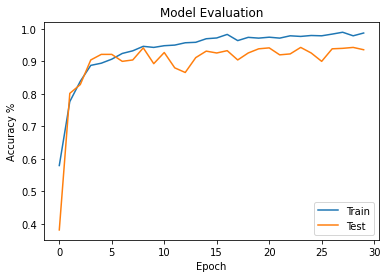

In [ ]:
import matplotlib.pyplot as plt

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('Model Evaluation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.legend(['Train', 'Test'])
plt.savefig('Model EValuation Plot')
plt.show()

In [ ]:
predictions = model.predict(X_test)
print(predictions)
predictions=predictions.argmax(axis=1)
predictions = predictions.astype(int).flatten()
predictions = (lb.inverse_transform((predictions)))
predictions = pd.DataFrame({'Predicted Values': predictions})

# ACTUAL LABELS
actual=y_test.argmax(axis=1)
actual = actual.astype(int).flatten()
actual = (lb.inverse_transform((actual)))
actual = pd.DataFrame({'Actual Values': actual})

# COMBINE BOTH
finaldf = actual.join(predictions)
finaldf[140:150]

[[5.5189635e-06 4.3267482e-06 1.0443352e-03 ... 1.3909444e-04
  2.8429788e-06 5.9764585e-05]
 [1.7657190e-05 7.1232487e-04 4.8079887e-06 ... 9.9890375e-01
  2.0275127e-04 1.5288750e-05]
 [1.8481457e-07 2.7627883e-07 2.4665969e-10 ... 1.2151805e-06
  9.9999714e-01 4.6566839e-09]
 ...
 [7.6723336e-05 1.1307011e-02 9.6299649e-05 ... 6.3841068e-03
  3.0762649e-06 9.7910041e-01]
 [9.6130216e-01 3.2038483e-04 1.8832413e-02 ... 3.3738298e-04
  1.5607879e-02 3.2697378e-03]
 [7.1583623e-03 4.4961947e-05 8.7272805e-01 ... 2.8160654e-03
  6.4632732e-05 1.1624377e-03]]


,Actual Values,Predicted Values
140,Angry,Angry
141,Happy,Happy
142,Disgust,Disgust
143,Disgust,Disgust
144,Angry,Angry
145,Sad,Neutral
146,Disgust,Disgust
147,Angry,Angry
148,Happy,Happy
149,Sad,Sad


## Predictions and confusion matrix

Convert model predictions to label strings, compare with actual labels, and visualize results with a confusion matrix to evaluate per-class performance.

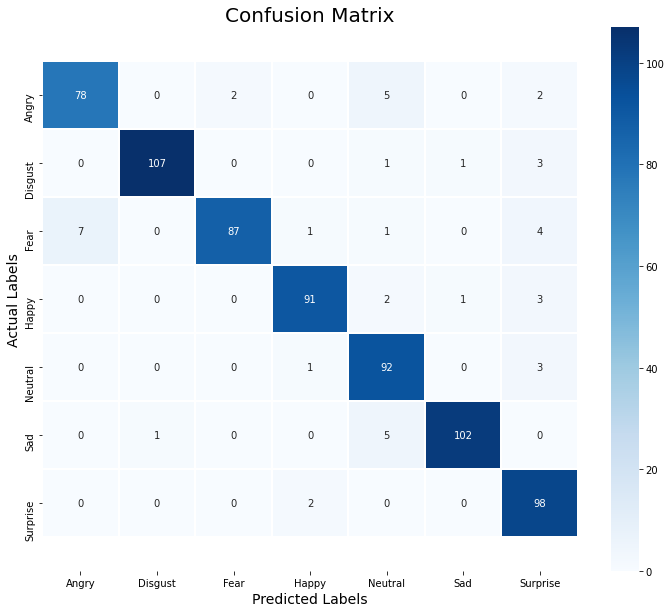

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns


cm = confusion_matrix(actual, predictions)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in lb.classes_] , columns = [i for i in lb.classes_])
ax = sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5)
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.savefig('Initial_Model_Confusion_Matrix.png')
plt.show()